# SAS Application: LeJEPA vs Supervised

## 1. Imports
### 1.1 Install packages

In [1]:
!pip install timm --quiet
!pip install dcor --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00


### 1.2 Import libraries

In [2]:
import os
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from torchvision.datasets import VOCSegmentation
from sklearn.decomposition import PCA
from sklearn.metrics import jaccard_score
from scipy.stats import spearmanr
from scipy.stats import bootstrap as scipy_bootstrap
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import dcor
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import warnings
warnings.filterwarnings('ignore') # for dcor

### 1.3 Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Globals

### 2.1 General globals + ViT config

In [4]:
SEED = 42

# dataset
IMAGENET_ROOT_VAL = "/content/drive/MyDrive/CV_project/data/imagenet100/imagenet1k/val_filtered"

# architecture/model
ARCH = "vit_small_patch16_224"
NUM_CLASSES = 100
IMG_SIZE = 224

SUPERVISED_CKPT_DIR = f"/content/drive/MyDrive/CV_project/checkpoints/supervised_{ARCH}/"
LEJEPA_CKPT_DIR = f"/content/drive/MyDrive/CV_project/checkpoints/lejepa_{ARCH}/"
SUPERVISED_BACKBONE_PATH = os.path.join(SUPERVISED_CKPT_DIR, "best_backbone.pt")
SUPERVISED_FULL_CKPT_PATH = os.path.join(SUPERVISED_CKPT_DIR, "best_checkpoint.pt")
LEJEPA_BACKBONE_PATH = os.path.join(LEJEPA_CKPT_DIR, "best_backbone.pt")
LEJEPA_HEAD_PATH = os.path.join(LEJEPA_CKPT_DIR, "linear_head.pt")

# vit
EMBED_DIM = 384
GRID_SIZE = 14  # 224 / 16, constant across blocks (patch count doesn't change with depth)

# layer-by-layer analysis
HOOK_LAYERS_VIT = [2, 5, 8, 11]

# LeJEPA probe
LEJEPA_PROBE_BLOCKS = [10, 11]
LEJEPA_PROBE_DIM = EMBED_DIM * 2

# SAS metrics
SAS_METRICS = ["sas_corr", "sas_dep", "sas_loc"]

MASS_THRESHOLDS = [0.4, 0.5, 0.6, 0.7, 0.8] # fraction of mass retained (from DINO)

# boostrap for statistical test
# resampling with replacement over images
N_BOOTSTRAP = 2000
N_QUALITATIVE_EXAMPLES = 6


# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# save path
SAVE_PATH = "/content/drive/MyDrive/CV_project/outputs/sas_lejepa_vs_sup"
os.makedirs(SAVE_PATH, exist_ok=True)
SAVE_PATH = Path(SAVE_PATH)

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Layer-by-layer analysis grid: {HOOK_LAYERS_VIT}")

Device: cuda
Layer-by-layer analysis grid: [2, 5, 8, 11]


### 2.2 CNN config

In [5]:
ARCH_CNN = "resnet50"
EMBED_DIM_CNN = 2048
HOOK_LAYERS_RESNET = ["layer1", "layer2", "layer3", "layer4"]

# path
SUPERVISED_CNN_CKPT_DIR = f"/content/drive/MyDrive/CV_project/checkpoints/supervised_{ARCH_CNN}/"
LEJEPA_CNN_CKPT_DIR = f"/content/drive/MyDrive/CV_project/checkpoints/lejepa_{ARCH_CNN}/"
SUPERVISED_CNN_BACKBONE_PATH = os.path.join(SUPERVISED_CNN_CKPT_DIR, "best_backbone.pt")
SUPERVISED_CNN_FULL_CKPT_PATH = os.path.join(SUPERVISED_CNN_CKPT_DIR, "best_checkpoint.pt")
LEJEPA_CNN_BACKBONE_PATH = os.path.join(LEJEPA_CNN_CKPT_DIR, "best_backbone.pt")
LEJEPA_CNN_HEAD_PATH = os.path.join(LEJEPA_CNN_CKPT_DIR, "linear_head.pt")

print(f"CNN hook layers: {HOOK_LAYERS_RESNET}")

CNN hook layers: ['layer1', 'layer2', 'layer3', 'layer4']


## 3. Utils

### 3.1 Seed for reproducibility

In [6]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


### 3.2 SAS core functions

In [7]:
def threshold_by_mass(map2d, tau):
    """
    Thresholding "by mass" (from DINO): sorts values in
    descending order and retains pixels that sum up to tau of the total mass
    """
    flat = map2d.flatten()
    order = np.argsort(flat)[::-1]
    cumsum = np.cumsum(flat[order])
    total = cumsum[-1] if cumsum[-1] > 0 else 1e-12
    cutoff_idx = np.searchsorted(cumsum, tau * total)
    mask = np.zeros_like(flat, dtype=bool)
    mask[order[:cutoff_idx + 1]] = True
    return mask.reshape(map2d.shape)

def compute_iou(mask_a, mask_b):
    """IoU between two binary masks"""
    return jaccard_score(mask_a.flatten(), mask_b.flatten(), zero_division=0)

def sas_corr(saliency_map, pca_map):
    """spearman correlation"""
    r, _ = spearmanr(saliency_map.flatten(), pca_map.flatten())
    return 0.0 if np.isnan(r) else r

def sas_dep(saliency_map, pca_map):
    """distance correlation"""
    return dcor.distance_correlation(saliency_map.flatten(), pca_map.flatten())

def sas_loc(saliency_map, pca_map, thresholds=MASS_THRESHOLDS):
    """AUITC, average IoU between the two maps thresholded by mass at different thresholds tau"""
    ious = [compute_iou(threshold_by_mass(saliency_map, t), threshold_by_mass(pca_map, t)) for t in thresholds]
    return float(np.mean(ious))


def get_pca_map(patch_tokens, grid_size=GRID_SIZE):
    """
    Extract pca map
    """
    norm_tokens = patch_tokens / (np.linalg.norm(patch_tokens, axis=1, keepdims=True) + 1e-12)
    similarity_matrix = np.dot(norm_tokens, norm_tokens.T) # [196, 196]
    degrees = similarity_matrix.sum(axis=1) # [196]
    foreground_anchor_idx = np.argmin(degrees) # foreground

    # PCA
    pca = PCA(n_components=1)
    component = pca.fit_transform(patch_tokens).reshape(-1) # [196]
    explained_variance = pca.explained_variance_ratio_[0]

    # pca sign
    sign_flipped = bool(component[foreground_anchor_idx] < component.mean())
    if sign_flipped:
        component = -component

    grid = component.reshape(grid_size, grid_size)
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-12)
    return grid, explained_variance, sign_flipped

def bootstrap_mean_ci(values, n_resamples=N_BOOTSTRAP, seed=SEED):
    values = np.asarray(values)
    rng = np.random.default_rng(seed)
    res = scipy_bootstrap((values,), np.mean, n_resamples=n_resamples, random_state=rng, method="basic")
    return values.mean(), res.confidence_interval.low, res.confidence_interval.high

In [8]:
def summarize_by_layer(df, name, hook_layers=HOOK_LAYERS_VIT):
    rows = []
    for layer in hook_layers:
        sub = df[df["layer"] == layer]
        for metric in SAS_METRICS:
            mean, lo, hi = bootstrap_mean_ci(sub[metric].values)
            rows.append({"model": name, "layer": layer, "metric": metric, "mean": mean, "ci_low": lo, "ci_high": hi})
    return pd.DataFrame(rows)

def sas_gap(df, layer, col):
    sub = df[df["layer"] == layer]
    correct_vals = sub.loc[sub["correct"] == 1, col]
    incorrect_vals = sub.loc[sub["correct"] == 0, col]
    if len(incorrect_vals) < 5:
        return {"gap": np.nan, "p_value": np.nan, "n_correct": len(correct_vals), "n_incorrect": len(incorrect_vals)}
    gap = correct_vals.mean() - incorrect_vals.mean()
    _, p = mannwhitneyu(correct_vals, incorrect_vals, alternative="two-sided")
    return {"gap": gap, "p_value": p, "n_correct": len(correct_vals), "n_incorrect": len(incorrect_vals)}

In [17]:
def evaluate_model(name, backbone, head, extract_fn, dataset, hook_layers, n_images=None):
    n = len(dataset) if n_images is None else min(n_images, len(dataset))
    rows = []
    for idx in tqdm(range(n), desc=f"SAS - {name}"):
        img_tensor, true_label = dataset[idx]
        saliency_by_layer, tokens_by_layer, pred_class = extract_fn(backbone, head, img_tensor, hook_layers)
        correct = int(pred_class == true_label)

        for layer in hook_layers:
            #print(f"Layer: {layer}")
            saliency_val = saliency_by_layer[layer]
            if torch.is_tensor(saliency_val):
                # ViT rollout
                saliency_raw = saliency_val[0, 1:].cpu().numpy().reshape(GRID_SIZE, GRID_SIZE)
            else:
                # CNN Grad-CAM already 2D numpy array
                saliency_raw = saliency_val
            saliency_norm = (saliency_raw - saliency_raw.min()) / (saliency_raw.max() - saliency_raw.min() + 1e-12)

            token_val = tokens_by_layer[layer]
            if isinstance(token_val, tuple):
                # CNN: (tokens, grid_size) numpy, grid change by layer
                patch_tokens, grid_size = token_val
            else:
                # ViT: tensor without token CLS
                patch_tokens = token_val[0, 1:, :].cpu().numpy()
                grid_size = GRID_SIZE
            pca_norm, pc1_var, sign_flipped = get_pca_map(patch_tokens, grid_size=grid_size)

            rows.append({
                "idx": idx, "layer": layer,
                "true_label": true_label,
                "pred_class": pred_class,
                "correct": correct,
                "sas_corr": sas_corr(saliency_norm, pca_norm),
                "sas_dep": sas_dep(saliency_norm, pca_norm),
                "sas_loc": sas_loc(saliency_raw, pca_norm),
                "pc1_variance": pc1_var,
                "sign_flipped": sign_flipped,
            })
    return pd.DataFrame(rows)

### 3.3 Model loading adapters

#### 3.3.1 ViT model loading adapters

In [10]:
def build_vit_full_tokens(dynamic_img_size=False):
    """ViT-S/16 with full tokens"""
    return timm.create_model(
        "vit_small_patch16_224", pretrained=False, num_classes=0,
        global_pool="", dynamic_img_size=dynamic_img_size,
    )

def _strip_prefix(state_dict, prefix):
    """Filter+strip a leftover nn.Sequential prefix before it ever reaches load_state_dict"""
    return {k[len(prefix):]: v for k, v in state_dict.items() if k.startswith(prefix)}


def load_supervised_vit(backbone_ckpt_path):
    state = torch.load(backbone_ckpt_path, map_location=DEVICE)
    stripped = _strip_prefix(state["backbone_state"], "0.")
    backbone = build_vit_full_tokens(dynamic_img_size=False)
    missing, unexpected = backbone.load_state_dict(stripped, strict=False)
    if missing or unexpected:
        print(f"[WARNING] supervised backbone load mismatch: {missing}, {unexpected}")
    backbone.eval().to(DEVICE)
    return backbone

def load_supervised_head(full_ckpt_path, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
    state = torch.load(full_ckpt_path, map_location=DEVICE)
    head_state = _strip_prefix(state["model_state"], "1.")
    head = nn.Linear(embed_dim, num_classes)
    head.load_state_dict(head_state)
    head.eval().to(DEVICE)
    return head

def load_lejepa_vit(backbone_ckpt_path):
    """No prefix to strip
    LeJEPA saves the raw timm module directly"""
    state = torch.load(backbone_ckpt_path, map_location=DEVICE)
    backbone = build_vit_full_tokens(dynamic_img_size=True)  # matches training-time config
    missing, unexpected = backbone.load_state_dict(state["backbone_state"], strict=False)
    if missing or unexpected:
        print(f"[WARNING] LeJEPA backbone load mismatch: {missing}, {unexpected}")
    backbone.eval().to(DEVICE)
    return backbone

def load_lejepa_head(head_ckpt_path, probe_dim=LEJEPA_PROBE_DIM, num_classes=NUM_CLASSES):
    state = torch.load(head_ckpt_path, map_location=DEVICE)
    head = nn.Sequential(nn.LayerNorm(probe_dim), nn.Linear(probe_dim, num_classes))
    head.load_state_dict(state["head_state"])
    head.eval().to(DEVICE)
    print(f"LeJEPA (vit) probe val_acc1 at save time: {state.get('val_acc1', 'n/a')}")
    return head

def prepare_for_rollout(vit_model):
    """
    Disable the fused SDPA path on every block
    so attention weights become accessible via a hook
    """
    for block in vit_model.blocks:
        block.attn.fused_attn = False

#### 3.3.2 CNN model loading adapters

In [11]:
def build_resnet50():
    return timm.create_model("resnet50", pretrained=False, num_classes=0)

def load_supervised_resnet(backbone_ckpt_path):
    state = torch.load(backbone_ckpt_path, map_location=DEVICE)
    stripped = _strip_prefix(state["backbone_state"], "0.")
    backbone = build_resnet50()
    missing, unexpected = backbone.load_state_dict(stripped, strict=False)
    if missing or unexpected:
        print(f"[WARNING] supervised ResNet backbone load mismatch: {missing}, {unexpected}")
    backbone.eval().to(DEVICE)
    return backbone

def load_supervised_resnet_head(full_ckpt_path, embed_dim=EMBED_DIM_CNN, num_classes=NUM_CLASSES):
    state = torch.load(full_ckpt_path, map_location=DEVICE)
    head_state = _strip_prefix(state["model_state"], "1.")
    head = nn.Linear(embed_dim, num_classes)
    head.load_state_dict(head_state)
    head.eval().to(DEVICE)
    return head

def load_lejepa_resnet(backbone_ckpt_path):
    """No prefix because the raw backbone is saved in LeJEPA"""
    state = torch.load(backbone_ckpt_path, map_location=DEVICE)
    backbone = build_resnet50()
    missing, unexpected = backbone.load_state_dict(state["backbone_state"], strict=False)
    if missing or unexpected:
        print(f"[WARNING] LeJEPA ResNet backbone load mismatch: {missing}, {unexpected}")
    backbone.eval().to(DEVICE)
    return backbone

def load_lejepa_resnet_head(head_ckpt_path, probe_dim=EMBED_DIM_CNN, num_classes=NUM_CLASSES):
    state = torch.load(head_ckpt_path, map_location=DEVICE)
    head = nn.Sequential(nn.LayerNorm(probe_dim), nn.Linear(probe_dim, num_classes))
    head.load_state_dict(state["head_state"])
    head.eval().to(DEVICE)
    print(f"LeJEPA (ResNet) probe val_acc1 at save time: {state.get('val_acc1', 'n/a')}")
    return head

### 3.4 Saliency map

#### 3.4.1 Attention Rollout

In [12]:
def register_all_attention_hooks(vit_model):
    attn_list = []
    def _make_hook():
        def _hook(module, inputs, output):
            attn_list.append(inputs[0].detach())  # input to attn_drop = post-softmax attention
        return _hook
    handles = [b.attn.attn_drop.register_forward_hook(_make_hook()) for b in vit_model.blocks]
    return handles, attn_list

def register_block_output_hooks(vit_model, block_indices):
    outputs = {}
    def _make_hook(idx):
        def _hook(module, inp, out):
            outputs[idx] = out.detach()
        return _hook
    handles = [vit_model.blocks[i].register_forward_hook(_make_hook(i)) for i in block_indices]
    return handles, outputs

def compute_rollout_by_layer(attn_list, hook_layers):
    n_tokens = attn_list[0].shape[-1]
    eye = torch.eye(n_tokens, device=attn_list[0].device)
    rollout = None
    rollout_by_layer = {}
    for i, attn in enumerate(attn_list):
        attn_avg = attn[0].mean(dim=0)  # mean over heads -> (n_tokens, n_tokens)
        a_hat = 0.5 * attn_avg + 0.5 * eye  # residual correction
        a_hat = a_hat / a_hat.sum(dim=-1, keepdim=True) # re-normalize rows to sum to 1
        rollout = a_hat if rollout is None else a_hat @ rollout
        if i in hook_layers:
            rollout_by_layer[i] = rollout.clone()
    return rollout_by_layer

@torch.no_grad()
def extract_supervised(backbone, head, img_tensor, hook_layers=HOOK_LAYERS_VIT):
    attn_handles, attn_list = register_all_attention_hooks(backbone)
    tok_handles, tok_out = register_block_output_hooks(backbone, hook_layers)

    normed_out = {}
    def _norm_hook(module, inp, out):
        normed_out["final"] = out.detach()
    norm_handle = backbone.norm.register_forward_hook(_norm_hook)

    try:
        _ = backbone(img_tensor.unsqueeze(0).to(DEVICE))
    finally:
        for h in attn_handles:
            h.remove()
        for h in tok_handles:
            h.remove()
        norm_handle.remove()

    rollout_by_layer = compute_rollout_by_layer(attn_list, hook_layers)
    tokens_by_layer = {l: tok_out[l] for l in hook_layers}

    cls_last = normed_out["final"][0, 0, :]   # CLS post-normalization
    logits = head(cls_last.unsqueeze(0))
    pred_class = int(logits.argmax(dim=1).item())
    return rollout_by_layer, tokens_by_layer, pred_class

@torch.no_grad()
def extract_lejepa(backbone, head, img_tensor, hook_layers=HOOK_LAYERS_VIT, probe_blocks=LEJEPA_PROBE_BLOCKS):
    attn_handles, attn_list = register_all_attention_hooks(backbone)
    needed_blocks = sorted(set(hook_layers) | set(probe_blocks))
    tok_handles, tok_out = register_block_output_hooks(backbone, needed_blocks)
    try:
        _ = backbone(img_tensor.unsqueeze(0).to(DEVICE))
    finally:
        for h in attn_handles:
            h.remove()
        for h in tok_handles:
            h.remove()

    rollout_by_layer = compute_rollout_by_layer(attn_list, hook_layers)
    tokens_by_layer = {l: tok_out[l] for l in hook_layers}

    probe_input = torch.cat([tok_out[b][0, 0, :] for b in probe_blocks], dim=-1)
    logits = head(probe_input.unsqueeze(0))
    pred_class = int(logits.argmax(dim=1).item())
    return rollout_by_layer, tokens_by_layer, pred_class

#### 3.4.2 CNN Grad-CAM

In [13]:
def register_multi_layer_gradcam_hooks(backbone, layer_names):
    activations, gradients = {}, {}
    modules = dict(backbone.named_modules())
    handles = []
    for name in layer_names:
        module = modules[name]
        def _fwd(m, i, o, n=name):
            activations[n] = o
        def _bwd(m, grad_input, grad_output, n=name):
            gradients[n] = grad_output[0]
        handles.append(module.register_forward_hook(_fwd))
        handles.append(module.register_full_backward_hook(_bwd))
    return handles, activations, gradients

def extract_resnet(backbone, head, img_tensor, hook_layers=HOOK_LAYERS_RESNET):
    backbone.zero_grad(set_to_none=True)
    head.zero_grad(set_to_none=True)
    handles, activations, gradients = register_multi_layer_gradcam_hooks(backbone, hook_layers)
    img = img_tensor.unsqueeze(0).to(DEVICE)
    try:
        pooled = backbone(img)  # (1, 2048) grad-enabled (num_classes=0 -> already pooled)
        logits = head(pooled)
        pred_class = logits.argmax(dim=1)
        target = logits[0, pred_class[0]]
        target.backward()
    finally:
        for h in handles:
            h.remove()

    cam_by_layer = {}
    tokens_by_layer = {}  # (tokens, grid_size) per layer
    for name in hook_layers:
        act = activations[name][0]  # (C, H, W)
        grad = gradients[name][0] # (C, H, W)
        weights = grad.mean(dim=(1, 2)) # (C,) global-average-pooled gradient
        cam = F.relu((weights[:, None, None] * act).sum(dim=0))
        cam_by_layer[name] = cam.detach().cpu().numpy()

        h, w = act.shape[1], act.shape[2]
        tokens = act.detach().permute(1, 2, 0).reshape(h * w, -1).cpu().numpy()  # (H*W, C)
        tokens_by_layer[name] = (tokens, h)

    pred_class_idx = int(pred_class.item())
    return cam_by_layer, tokens_by_layer, pred_class_idx

## 4. Data

### 4.1 ImageNet-100 validation set

#### 4.1.1 Export data from Drive to local colab runtime

In [14]:
IMAGENET_ZIP_PATH = "/content/drive/MyDrive/CV_project/data/imagenet100_val_filtered.zip"
LOCAL_IMAGENET_ROOT_VAL = "/content/imagenet100_val"

if not os.path.isdir(LOCAL_IMAGENET_ROOT_VAL):
    local_zip_path = "/content/val_filtered.zip"

    print(f"Copying the zip archive from Drive: {IMAGENET_ZIP_PATH} ...")
    !cp "{IMAGENET_ZIP_PATH}" "{local_zip_path}"

    print("Copy completed, extracting the archive locally...")
    !unzip -q "{local_zip_path}" -d "{LOCAL_IMAGENET_ROOT_VAL}"

    # remove the zip
    os.remove(local_zip_path)
    print(f"Extraction completed")
else:
    # local copy already exists, skip
    print(f"Local copy already exists at {LOCAL_IMAGENET_ROOT_VAL}, skipping copy and extraction")

IMAGENET_ROOT_VAL = Path(LOCAL_IMAGENET_ROOT_VAL) / "val_filtered"

Copying the zip archive from Drive: /content/drive/MyDrive/CV_project/data/imagenet100_val_filtered.zip ...
Copy completed, extracting the archive locally...
Extraction completed


#### 4.1.2 Load data

In [15]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

val_transform = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_dataset_raw = ImageFolder(IMAGENET_ROOT_VAL)  # un-normalized, for plotting + labels
val_dataset = ImageFolder(IMAGENET_ROOT_VAL, transform=val_transform)

print(f"Val set: {len(val_dataset)} images, {len(val_dataset.classes)} classes")

Val set: 5000 images, 100 classes


## 5. Network

### 5.1 ViT backbones + heads

In [18]:
supervised_backbone = load_supervised_vit(SUPERVISED_BACKBONE_PATH)
supervised_head = load_supervised_head(SUPERVISED_FULL_CKPT_PATH)
prepare_for_rollout(supervised_backbone)

lejepa_backbone = load_lejepa_vit(LEJEPA_BACKBONE_PATH)
lejepa_head = load_lejepa_head(LEJEPA_HEAD_PATH)
prepare_for_rollout(lejepa_backbone)

LeJEPA (vit) probe val_acc1 at save time: 62.96


### 5.2 ResNet-50 backbones + heads

In [19]:
supervised_resnet = load_supervised_resnet(SUPERVISED_CNN_BACKBONE_PATH)
supervised_resnet_head = load_supervised_resnet_head(SUPERVISED_CNN_FULL_CKPT_PATH)

lejepa_resnet = load_lejepa_resnet(LEJEPA_CNN_BACKBONE_PATH)
lejepa_resnet_head = load_lejepa_resnet_head(LEJEPA_CNN_HEAD_PATH)

LeJEPA (ResNet) probe val_acc1 at save time: 66.14


## 6. Evaluation

## 6.1 ViT branch

### 6.1.1 Qualitative check

A few images, rollout + PCA at each of the four `HOOK_LAYERS_VIT` depths, both models.

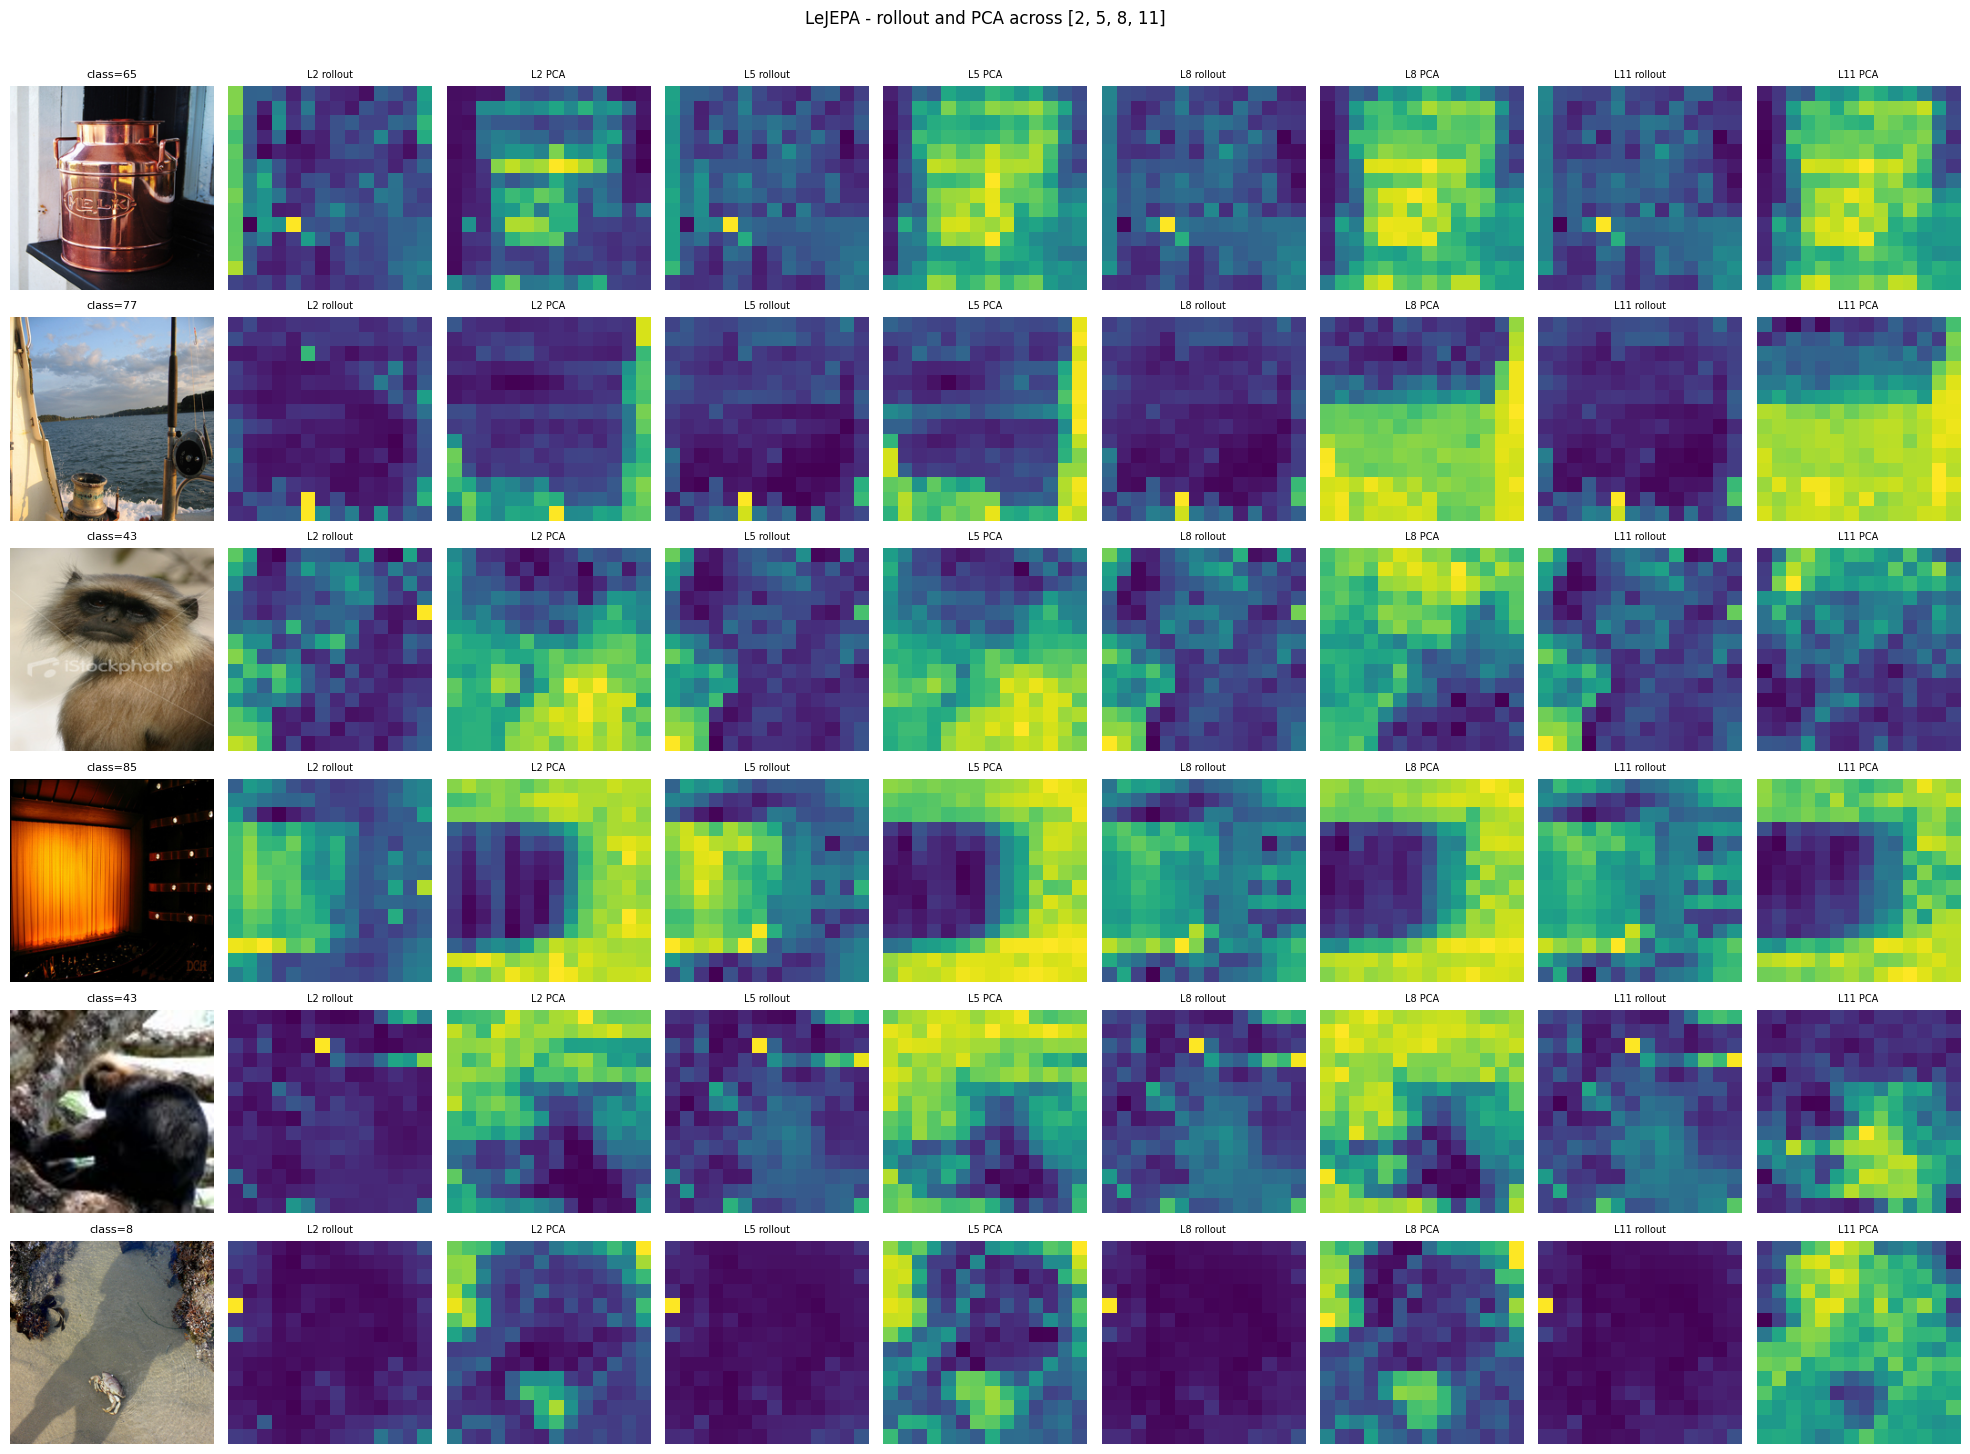

In [20]:
qual_indices = np.random.default_rng(SEED).choice(len(val_dataset), N_QUALITATIVE_EXAMPLES, replace=False)

n_cols = 1 + 2 * len(HOOK_LAYERS_VIT)  # image + (saliency, pca) per layer
fig, axes = plt.subplots(N_QUALITATIVE_EXAMPLES, n_cols, figsize=(2.2 * n_cols, 2.4 * N_QUALITATIVE_EXAMPLES))

for row, idx in enumerate(qual_indices):
    img_tensor, label = val_dataset[idx]
    img_raw, _ = val_dataset_raw[idx]
    rollout_by_layer, tokens_by_layer, _ = extract_lejepa(lejepa_backbone, lejepa_head, img_tensor)

    axes[row, 0].imshow(img_raw.resize((IMG_SIZE, IMG_SIZE)))
    axes[row, 0].set_title(f"class={label}", fontsize=8)
    axes[row, 0].axis("off")

    for j, layer in enumerate(HOOK_LAYERS_VIT):
        saliency_raw = rollout_by_layer[layer][0, 1:].cpu().numpy().reshape(GRID_SIZE, GRID_SIZE)
        patch_tokens = tokens_by_layer[layer][0, 1:, :].cpu().numpy()
        pca_norm, _, _ = get_pca_map(patch_tokens)

        axes[row, 1 + 2*j].imshow(saliency_raw, cmap="viridis")
        axes[row, 1 + 2*j].set_title(f"L{layer} rollout", fontsize=7)
        axes[row, 2 + 2*j].imshow(pca_norm, cmap="viridis")
        axes[row, 2 + 2*j].set_title(f"L{layer} PCA", fontsize=7)

    for ax in axes[row, 1:]:
        ax.axis("off")

plt.suptitle(f"LeJEPA - rollout and PCA across {HOOK_LAYERS_VIT}", y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH / "vit_qualitative_lejepa_layerwise.png", dpi=100, bbox_inches="tight")
plt.show()


#### 6.1.2 SAS computation

Main SAS computation, layer-by-layer

In [21]:
N_EVAL_IMAGES = None  # None = full validation set, int (e.g. 500) for a quick first pass

df_supervised = evaluate_model("Supervised", supervised_backbone, supervised_head, extract_supervised, val_dataset, HOOK_LAYERS_VIT, n_images=N_EVAL_IMAGES)
df_lejepa = evaluate_model("LeJEPA", lejepa_backbone, lejepa_head, extract_lejepa, val_dataset, HOOK_LAYERS_VIT, n_images=N_EVAL_IMAGES)

df_supervised.to_csv(SAVE_PATH / "vit_supervised_results.csv", index=False)
df_lejepa.to_csv(SAVE_PATH / "vit_lejepa_results.csv", index=False)

acc_sup = df_supervised.drop_duplicates("idx")["correct"].mean()
acc_lej = df_lejepa.drop_duplicates("idx")["correct"].mean()
print(f"Supervised accuracy on this run: {acc_sup:.1%}")
print(f"LeJEPA accuracy on this run: {acc_lej:.1%}")


SAS - Supervised:   0%|          | 0/5000 [00:00<?, ?it/s]

SAS - LeJEPA:   0%|          | 0/5000 [00:00<?, ?it/s]

Supervised accuracy on this run: 62.8%
LeJEPA accuracy on this run: 62.9%


#### 6.1.3 Layer-by-layer summary

In [22]:
summary = pd.concat([
    summarize_by_layer(df_supervised, "Supervised", hook_layers=HOOK_LAYERS_VIT),
    summarize_by_layer(df_lejepa, "LeJEPA", hook_layers=HOOK_LAYERS_VIT)
], ignore_index=True)

summary.to_csv(SAVE_PATH / "vit_summary_by_layer.csv", index=False)

pivot = summary.pivot_table(index=["metric", "layer"], columns="model", values="mean")
print(pivot.to_string())

model             LeJEPA  Supervised
metric   layer                      
sas_corr 2      0.176721    0.104950
         5      0.017991    0.235734
         8      0.110661    0.171260
         11     0.034528    0.102399
sas_dep  2      0.364107    0.380835
         5      0.383507    0.489643
         8      0.386724    0.449359
         11     0.374202    0.423932
sas_loc  2      0.352309    0.326650
         5      0.318896    0.379078
         8      0.350944    0.356769
         11     0.327038    0.340006


#### 6.1.4 SAS-gap (correct vs incorrect predictions), per layer

In [23]:
gap_rows = []
for model_name, df in [("Supervised", df_supervised), ("LeJEPA", df_lejepa)]:
    for layer in HOOK_LAYERS_VIT:
        for metric in SAS_METRICS:
            result = sas_gap(df, layer, metric)
            result.update({"model": model_name, "layer": layer, "metric": metric})
            gap_rows.append(result)

df_gap = pd.DataFrame(gap_rows)[["model", "layer", "metric", "gap", "p_value", "n_correct", "n_incorrect"]]
df_gap.to_csv(SAVE_PATH / "vit_sas_gap_by_layer.csv", index=False)
print(df_gap.to_string(index=False))


     model  layer   metric       gap  p_value  n_correct  n_incorrect
Supervised      2 sas_corr  0.031456 0.001137       3138         1862
Supervised      2  sas_dep  0.016448 0.007967       3138         1862
Supervised      2  sas_loc  0.010979 0.000615       3138         1862
Supervised      5 sas_corr  0.031772 0.012819       3138         1862
Supervised      5  sas_dep  0.016712 0.010503       3138         1862
Supervised      5  sas_loc  0.012311 0.004735       3138         1862
Supervised      8 sas_corr  0.019215 0.088660       3138         1862
Supervised      8  sas_dep  0.017226 0.005758       3138         1862
Supervised      8  sas_loc  0.007834 0.056873       3138         1862
Supervised     11 sas_corr  0.014997 0.163698       3138         1862
Supervised     11  sas_dep  0.015699 0.007518       3138         1862
Supervised     11  sas_loc  0.006379 0.103470       3138         1862
    LeJEPA      2 sas_corr -0.001430 0.824780       3147         1853
    LeJEPA      2  s

### 6.2 CNN branch

#### 6.2.1 Qualitative check

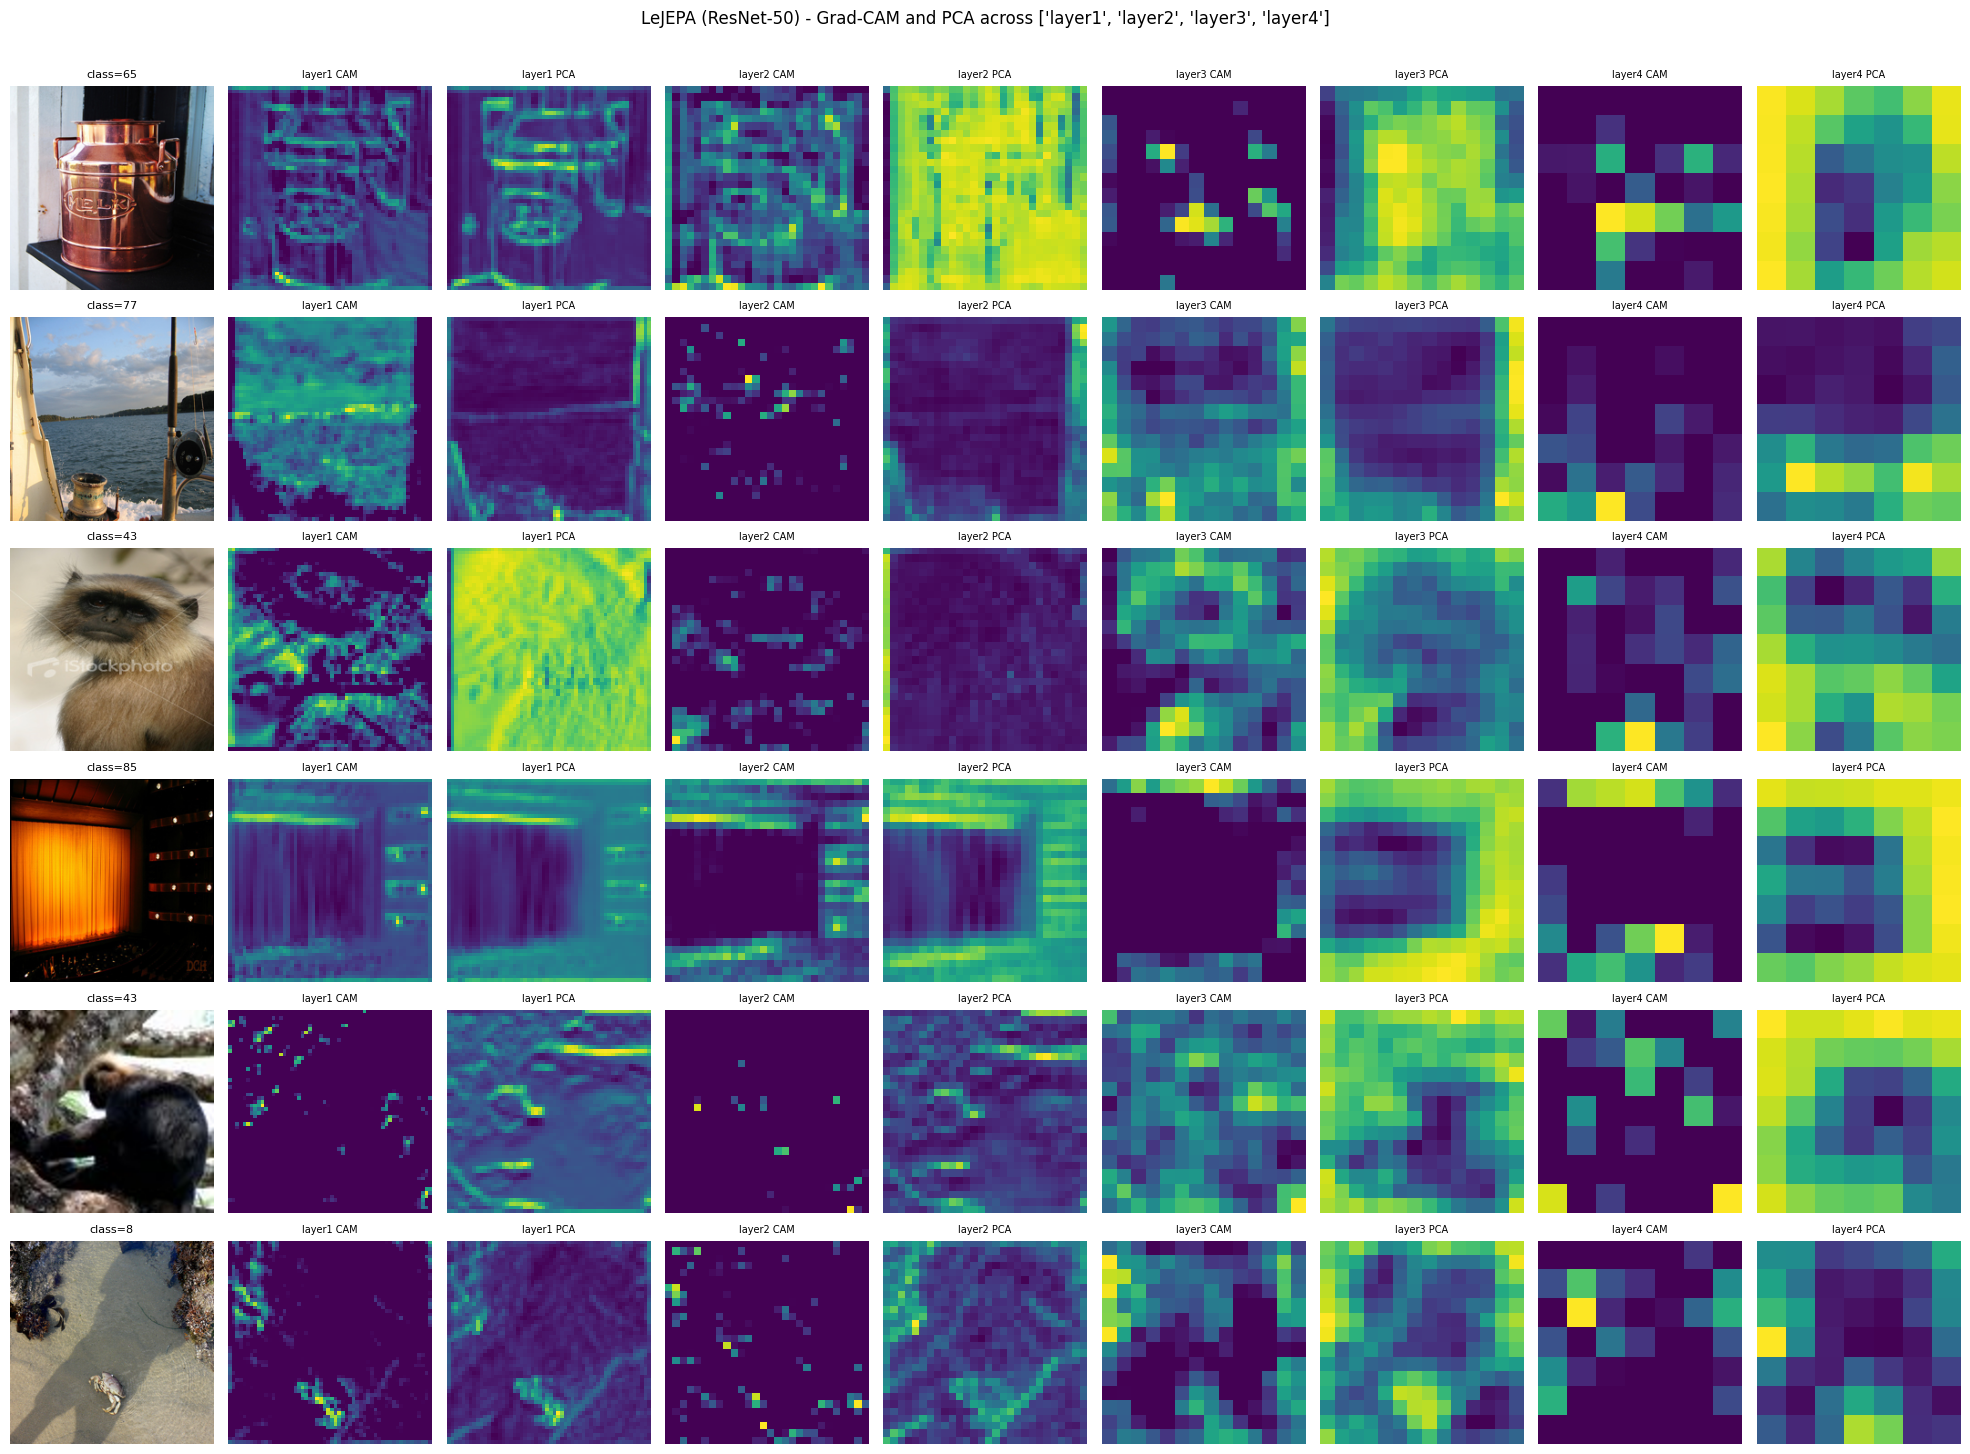

In [24]:
qual_indices_cnn = np.random.default_rng(SEED).choice(len(val_dataset), N_QUALITATIVE_EXAMPLES, replace=False)

n_cols_cnn = 1 + 2 * len(HOOK_LAYERS_RESNET)
fig, axes = plt.subplots(N_QUALITATIVE_EXAMPLES, n_cols_cnn, figsize=(2.2 * n_cols_cnn, 2.4 * N_QUALITATIVE_EXAMPLES))

for row, idx in enumerate(qual_indices_cnn):
    img_tensor, label = val_dataset[idx]
    img_raw, _ = val_dataset_raw[idx]
    cam_by_layer, tokens_by_layer, _ = extract_resnet(lejepa_resnet, lejepa_resnet_head, img_tensor)

    axes[row, 0].imshow(img_raw.resize((IMG_SIZE, IMG_SIZE)))
    axes[row, 0].set_title(f"class={label}", fontsize=8)
    axes[row, 0].axis("off")

    for j, name in enumerate(HOOK_LAYERS_RESNET):
        cam = cam_by_layer[name]
        tokens, grid = tokens_by_layer[name]
        pca_norm, _, _ = get_pca_map(tokens, grid_size=grid)

        axes[row, 1 + 2*j].imshow(cam, cmap="viridis")
        axes[row, 1 + 2*j].set_title(f"{name} CAM", fontsize=7)
        axes[row, 2 + 2*j].imshow(pca_norm, cmap="viridis")
        axes[row, 2 + 2*j].set_title(f"{name} PCA", fontsize=7)

    for ax in axes[row, 1:]:
        ax.axis("off")

plt.suptitle(f"LeJEPA (ResNet-50) - Grad-CAM and PCA across {HOOK_LAYERS_RESNET}", y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH / "resnet_qualitative_lejepa_layerwise.png", dpi=100, bbox_inches="tight")
plt.show()

#### 6.2.2 SAS computation, layer-by-layer

In [25]:
N_EVAL_IMAGES_CNN = None  # None = full validation set, int (e.g. 500) for a quick first pass

df_supervised_cnn = evaluate_model("Supervised", supervised_resnet, supervised_resnet_head, extract_resnet, val_dataset, HOOK_LAYERS_RESNET, n_images=N_EVAL_IMAGES_CNN)
df_lejepa_cnn = evaluate_model("LeJEPA", lejepa_resnet, lejepa_resnet_head, extract_resnet, val_dataset, HOOK_LAYERS_RESNET, n_images=N_EVAL_IMAGES_CNN)

df_supervised_cnn.to_csv(SAVE_PATH / "resnet_supervised_results.csv", index=False)
df_lejepa_cnn.to_csv(SAVE_PATH / "resnet_lejepa_results.csv", index=False)

acc_sup_cnn = df_supervised_cnn.drop_duplicates("idx")["correct"].mean()
acc_lej_cnn = df_lejepa_cnn.drop_duplicates("idx")["correct"].mean()
print(f"Supervised (ResNet-50) accuracy: {acc_sup_cnn:.1%}")
print(f"LeJEPA (ResNet-50) accuracy: {acc_lej_cnn:.1%}")

SAS - Supervised:   0%|          | 0/5000 [00:00<?, ?it/s]

SAS - LeJEPA:   0%|          | 0/5000 [00:00<?, ?it/s]

Supervised (ResNet-50) accuracy: 79.5%
LeJEPA (ResNet-50) accuracy: 66.1%


#### 6.2.3 Layer-by-layer summary

In [26]:
summary_cnn = pd.concat([
    summarize_by_layer(df_supervised_cnn, "Supervised", hook_layers=HOOK_LAYERS_RESNET),
    summarize_by_layer(df_lejepa_cnn, "LeJEPA", hook_layers=HOOK_LAYERS_RESNET),
], ignore_index=True)

summary_cnn.to_csv(SAVE_PATH / "resnet_summary_by_layer.csv", index=False)

pivot = summary.pivot_table(index=["metric", "layer"], columns="model", values="mean")
print(pivot.to_string())

model             LeJEPA  Supervised
metric   layer                      
sas_corr 2      0.176721    0.104950
         5      0.017991    0.235734
         8      0.110661    0.171260
         11     0.034528    0.102399
sas_dep  2      0.364107    0.380835
         5      0.383507    0.489643
         8      0.386724    0.449359
         11     0.374202    0.423932
sas_loc  2      0.352309    0.326650
         5      0.318896    0.379078
         8      0.350944    0.356769
         11     0.327038    0.340006


#### 6.2.4 SAS gap

In [27]:
gap_rows_cnn = []
for model_name, df in [("Supervised", df_supervised_cnn), ("LeJEPA", df_lejepa_cnn)]:
    for layer in HOOK_LAYERS_RESNET:
        for metric in SAS_METRICS:
            result = sas_gap(df, layer, metric)
            result.update({"model": model_name, "layer": layer, "metric": metric})
            gap_rows_cnn.append(result)

df_gap_cnn = pd.DataFrame(gap_rows_cnn)[["model", "layer", "metric", "gap", "p_value", "n_correct", "n_incorrect"]]
df_gap_cnn.to_csv(SAVE_PATH / "resnet_sas_gap_by_layer.csv", index=False)
print(df_gap_cnn.to_string(index=False))

     model  layer   metric       gap      p_value  n_correct  n_incorrect
Supervised layer1 sas_corr -0.016332 2.690592e-01       3975         1025
Supervised layer1  sas_dep -0.011091 2.107896e-01       3975         1025
Supervised layer1  sas_loc -0.003626 3.986218e-01       3975         1025
Supervised layer2 sas_corr -0.016960 1.937309e-01       3975         1025
Supervised layer2  sas_dep -0.010177 9.076453e-02       3975         1025
Supervised layer2  sas_loc -0.014887 5.313680e-03       3975         1025
Supervised layer3 sas_corr -0.009428 9.411610e-01       3975         1025
Supervised layer3  sas_dep  0.031005 4.922238e-06       3975         1025
Supervised layer3  sas_loc -0.013305 2.900135e-03       3975         1025
Supervised layer4 sas_corr -0.187511 4.295609e-76       3975         1025
Supervised layer4  sas_dep  0.142642 3.052638e-79       3975         1025
Supervised layer4  sas_loc -0.015572 9.853875e-09       3975         1025
    LeJEPA layer1 sas_corr  0.001339 8

## 7. Out-of-distribution test on PASCAL VOC 2012

### 7.1 Load dataset

In [28]:
VOC_ROOT = "./data"
VOC_YEAR = "2012"
VOC_SPLIT = "val"  # validation split

voc_img_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

voc_dataset_raw = VOCSegmentation(root=VOC_ROOT, year=VOC_YEAR, image_set=VOC_SPLIT, download=True)

def load_voc_item(idx):
    img_pil, mask_pil = voc_dataset_raw[idx]
    img_tensor = voc_img_transform(img_pil)
    return img_tensor, mask_pil

print(f"VOC 2012 val: {len(voc_dataset_raw)} images")

100%|██████████| 2.00G/2.00G [01:17<00:00, 25.9MB/s]


VOC 2012 val: 1449 images


In [29]:
def voc_mask_to_patch_grid(mask_pil, grid_size, img_size=IMG_SIZE):
    """
    Converts the VOC mask (0=background, 1-20=classes, 255=border/ignore)
    into a binary foreground/background grid at the resolution of patch tokens
    (GRID_SIZE x GRID_SIZE), consistent with saliency/PCA maps
    Border pixels (255) are excluded from the patch majority vote
    """
    mask = np.array(mask_pil.resize((img_size, img_size), Image.NEAREST))
    fg = (mask > 0) & (mask != 255)
    valid = (mask != 255)
    step = img_size // grid_size
    grid = np.zeros((grid_size, grid_size), dtype=bool)
    for i in range(grid_size):
        for j in range(grid_size):
            sl_i, sl_j = slice(i * step, (i + 1) * step), slice(j * step, (j + 1) * step)
            patch_valid = valid[sl_i, sl_j]
            if patch_valid.sum() > 0:
                grid[i, j] = (fg[sl_i, sl_j].sum() / patch_valid.sum()) > 0.5
    return grid

### 7.2 Evaluation on VOC

In [30]:
def evaluate_model_ood(name, backbone, head, extract_fn, hook_layers, n_images=None):
    n = len(voc_dataset_raw) if n_images is None else min(n_images, len(voc_dataset_raw))
    rows = []
    for idx in tqdm(range(n), desc=f"VOC OOD - {name}"):
        img_tensor, mask_pil = load_voc_item(idx)
        saliency_by_layer, tokens_by_layer, _ = extract_fn(backbone, head, img_tensor, hook_layers)

        for layer in hook_layers:
            saliency_val = saliency_by_layer[layer]
            if torch.is_tensor(saliency_val):
                saliency_raw = saliency_val[0, 1:].cpu().numpy().reshape(GRID_SIZE, GRID_SIZE)
            else:
                saliency_raw = saliency_val
            saliency_norm = (saliency_raw - saliency_raw.min()) / (saliency_raw.max() - saliency_raw.min() + 1e-12)

            token_val = tokens_by_layer[layer]
            if isinstance(token_val, tuple):
                patch_tokens, grid_size = token_val
            else:
                patch_tokens = token_val[0, 1:, :].cpu().numpy()
                grid_size = GRID_SIZE
            pca_norm, pc1_var, sign_flipped = get_pca_map(patch_tokens, grid_size=grid_size)
            gt_mask = voc_mask_to_patch_grid(mask_pil, grid_size=grid_size)

            rows.append({
                "idx": idx,
                "layer": layer,
                "sas_corr": sas_corr(saliency_norm, pca_norm),
                "sas_dep": sas_dep(saliency_norm, pca_norm),
                "sas_loc": sas_loc(saliency_raw, pca_norm),
                "iou_vs_gt": compute_iou(threshold_by_mass(saliency_raw, 0.6), gt_mask),
                "pc1_variance": pc1_var,
                "sign_flipped": sign_flipped
            })

    return pd.DataFrame(rows)

#### 7.2.1 ViT

In [31]:
N_EVAL_IMAGES_OOD = None  # None = full VOC val set, an int for a quick first pass

df_supervised_ood_vit = evaluate_model_ood("Supervised", supervised_backbone, supervised_head, extract_supervised, HOOK_LAYERS_VIT, n_images=N_EVAL_IMAGES_OOD)
df_lejepa_ood_vit = evaluate_model_ood("LeJEPA", lejepa_backbone, lejepa_head, extract_lejepa, HOOK_LAYERS_VIT, n_images=N_EVAL_IMAGES_OOD)

df_supervised_ood_vit.to_csv(SAVE_PATH / "vit_ood_voc_supervised.csv", index=False)
df_lejepa_ood_vit.to_csv(SAVE_PATH / "vit_ood_voc_lejepa.csv", index=False)

VOC OOD - Supervised:   0%|          | 0/1449 [00:00<?, ?it/s]

VOC OOD - LeJEPA:   0%|          | 0/1449 [00:00<?, ?it/s]

#### 7.2.2 CNN

In [32]:
df_supervised_ood_cnn = evaluate_model_ood("Supervised", supervised_resnet, supervised_resnet_head, extract_resnet, HOOK_LAYERS_RESNET, n_images=N_EVAL_IMAGES_OOD)
df_lejepa_ood_cnn = evaluate_model_ood("LeJEPA", lejepa_resnet, lejepa_resnet_head, extract_resnet, HOOK_LAYERS_RESNET, n_images=N_EVAL_IMAGES_OOD)

df_supervised_ood_cnn.to_csv(SAVE_PATH / "resnet_ood_voc_supervised.csv", index=False)
df_lejepa_ood_cnn.to_csv(SAVE_PATH / "resnet_ood_voc_lejepa.csv", index=False)

VOC OOD - Supervised:   0%|          | 0/1449 [00:00<?, ?it/s]

VOC OOD - LeJEPA:   0%|          | 0/1449 [00:00<?, ?it/s]

#### 7.2.3 Summary

In [33]:
def summarize_ood(df, name):
    rows = []
    for layer in df["layer"].unique():
        sub = df[df["layer"] == layer]
        for metric in SAS_METRICS + ["iou_vs_gt"]:
            mean, lo, hi = bootstrap_mean_ci(sub[metric].values)
            rows.append({"model": name, "layer": layer, "metric": metric, "mean": mean, "ci_low": lo, "ci_high": hi})
    return pd.DataFrame(rows)

ood_summary_vit = pd.concat([
    summarize_ood(df_supervised_ood_vit, "Supervised"),
    summarize_ood(df_lejepa_ood_vit, "LeJEPA")
], ignore_index=True)

ood_summary_cnn = pd.concat([
    summarize_ood(df_supervised_ood_cnn, "Supervised"),
    summarize_ood(df_lejepa_ood_cnn, "LeJEPA")
], ignore_index=True)

ood_summary_vit.to_csv(SAVE_PATH / "vit_ood_summary.csv", index=False)
ood_summary_cnn.to_csv(SAVE_PATH / "resnet_ood_summary.csv", index=False)

print("ViT on VOC")
pivot_vit = ood_summary_vit.pivot_table(index=["metric", "layer"], columns="model", values="mean")
print(pivot_vit.to_string())
print("ResNet-50 on VOC (OOD)")
pivot_cnn = ood_summary_cnn.pivot_table(index=["metric", "layer"], columns="model", values="mean")
print(pivot_cnn.to_string())

ViT on VOC
model              LeJEPA  Supervised
metric    layer                      
iou_vs_gt 2      0.258816    0.271387
          5      0.229620    0.327868
          8      0.255746    0.312139
          11     0.249467    0.306852
sas_corr  2      0.201483    0.139791
          5      0.024483    0.284842
          8      0.125661    0.214162
          11     0.033103    0.135918
sas_dep   2      0.374983    0.389848
          5      0.392552    0.504444
          8      0.384370    0.456547
          11     0.376035    0.431044
sas_loc   2      0.354144    0.333160
          5      0.318227    0.389176
          8      0.356344    0.363715
          11     0.318241    0.343822
ResNet-50 on VOC (OOD)
model               LeJEPA  Supervised
metric    layer                       
iou_vs_gt layer1  0.111933    0.109873
          layer2  0.117787    0.118744
          layer3  0.136022    0.152412
          layer4  0.183776    0.257259
sas_corr  layer1  0.020761    0.025303
         